<a href="https://colab.research.google.com/github/alviglio/AlbJupyters/blob/main/SivaGuenterPeterBook/Chapter02draft03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 2 — A simple degree-day snow model

![Saint Elias Mountains](https://upload.wikimedia.org/wikipedia/commons/4/45/Saint_Elias_Mountains.jpg?utm_source=commons.wikimedia.org&utm_campaign=index&utm_content=original)

## Purpose of this notebook

This notebook introduces the **degree-day factor method** for snowmelt and uses it as a first example of numerical modelling in hydrology.

The aim is not to build a complete snow model immediately. Instead, we build the model gradually, make a few deliberate mistakes, diagnose why they are wrong, and then add the missing physical constraints. This is often how numerical hydrological models are developed in practice: we start with a balance equation, implement it, inspect the result, and then check whether the result is physically possible.

By the end of the notebook, you should be able to explain:

1. how snowfall accumulates as snow water equivalent, `SWE`;
2. how temperature can be used to estimate snowmelt with a degree-day factor;
3. why fluxes such as snowmelt must be constrained by available storage;
4. why the order of operations within a time step matters;
5. how changing the time step or degree-day factor changes the model result.

The central storage equation is:

$$
SWE_{t+1} = SWE_t + P_s(t) - M(t)
$$

where $P_s(t)$ is snowfall and $M(t)$ is snowmelt during time step $t$.


## 1. Define a deliberately simple winter–summer experiment

We prescribe 12 time steps. You can think of them as months, but the same logic applies to days or weeks.

The experiment has two phases:

- **winter accumulation phase**: snowfall occurs and temperature is below freezing;
- **summer melt phase**: snowfall stops and temperature is above freezing.

This artificial example is useful because we know what the model should do before we run it: snow should accumulate during the cold period, then melt during the warm period, and neither snowmelt nor snow storage should ever become physically impossible.


In [1]:
P_s <- c(100, 100, 100, 100, 100, 100,
         0, 0, 0, 0, 0, 0)
Tdeg <- c(-10, -10, -10, -10, -10, -10,
          10, 10, 10, 10, 10, 10)


The vector `P_s` contains snowfall in `mm/timestep`. The vector `Tdeg` contains air temperature in degrees Celsius.

In this first example, all precipitation is already assumed to be snow. Later, in a complete model, we can partition total precipitation into rainfall and snowfall using temperature thresholds.

Before running the model, ask yourself:

- What should happen during the first six time steps?
- What should happen during the last six time steps?
- What values should never be negative?


## 2. First attempt: degree-day melt without constraints

The degree-day idea says that melt is proportional to temperature above a melt threshold:

$$
M(t) = k_{DDF}\,[T(t)-T_m]
$$

where:

- $M(t)$ is snowmelt in `mm/timestep`;
- $k_{DDF}$ is the degree-day factor in `mm/(°C timestep)`;
- $T(t)$ is air temperature;
- $T_m$ is the melt threshold temperature.

The first implementation below applies this formula directly. This is intentionally incomplete.


In [2]:
snowmodel01 <- function (snowfall, temperature, k_DDF, Tmelt=0, SWE_0=0) {
  # snowfall = vector in mm/timestep
  # temperature = vector in degC
  # k_DDF = Degree Day Factor mm/(degC*timestep)
  tmax <- length(snowfall)
  snowmelt <- rep(NA, tmax)
  SWE <- rep(NA, tmax + 1)
   SWE[1] <- SWE_0
  for (t in 1:tmax) {
    snowmelt[t] <- k_DDF*(temperature[t] - Tmelt)
    SWE[t+1] <- SWE[t] + snowfall[t] - snowmelt[t]
  }
  output <- cbind(t=1:tmax, snowfall=round(snowfall, 1),
                  temperature=round(temperature, 1), SWE=round(SWE[-1], 1),
                  snowmelt=round(snowmelt, 1))
  return(output)
}
snowmodel01(P_s, Tdeg, k_DDF=30)


t,snowfall,temperature,SWE,snowmelt
1,100,-10,400,-300
2,100,-10,800,-300
3,100,-10,1200,-300
4,100,-10,1600,-300
5,100,-10,2000,-300
6,100,-10,2400,-300
7,0,10,2100,300
8,0,10,1800,300
9,0,10,1500,300
10,0,10,1200,300


### What went wrong?

The storage balance was implemented as:

$$
SWE_{t+1} = SWE_t + P_s(t) - M(t)
$$

but the melt equation allowed `M` to become negative when temperature was below the melt threshold.

For example, if $T=-10\,^\circ C$, $T_m=0\,^\circ C$, and $k_{DDF}=30$, then:

$$
M = 30(-10-0) = -300 \text{ mm/timestep}
$$

Negative melt has no physical meaning. In the storage equation, subtracting a negative melt is equivalent to adding water to the snowpack. The first numerical lesson is therefore:

> A model equation may look reasonable, but its implementation must still enforce the physical domain of the variables.

For snowmelt, the first physical constraint is:

$$
M(t) \ge 0
$$


## 3. A plotting helper

The function below is only for visualization. It plots:

1. snowfall input;
2. snow water equivalent, `SWE`;
3. snowmelt output.

The examples are expanded from 12 coarse time steps to a smoother-looking sequence by repeating each value many times. This does not make the model more accurate; it only makes the conceptual figure easier to read.


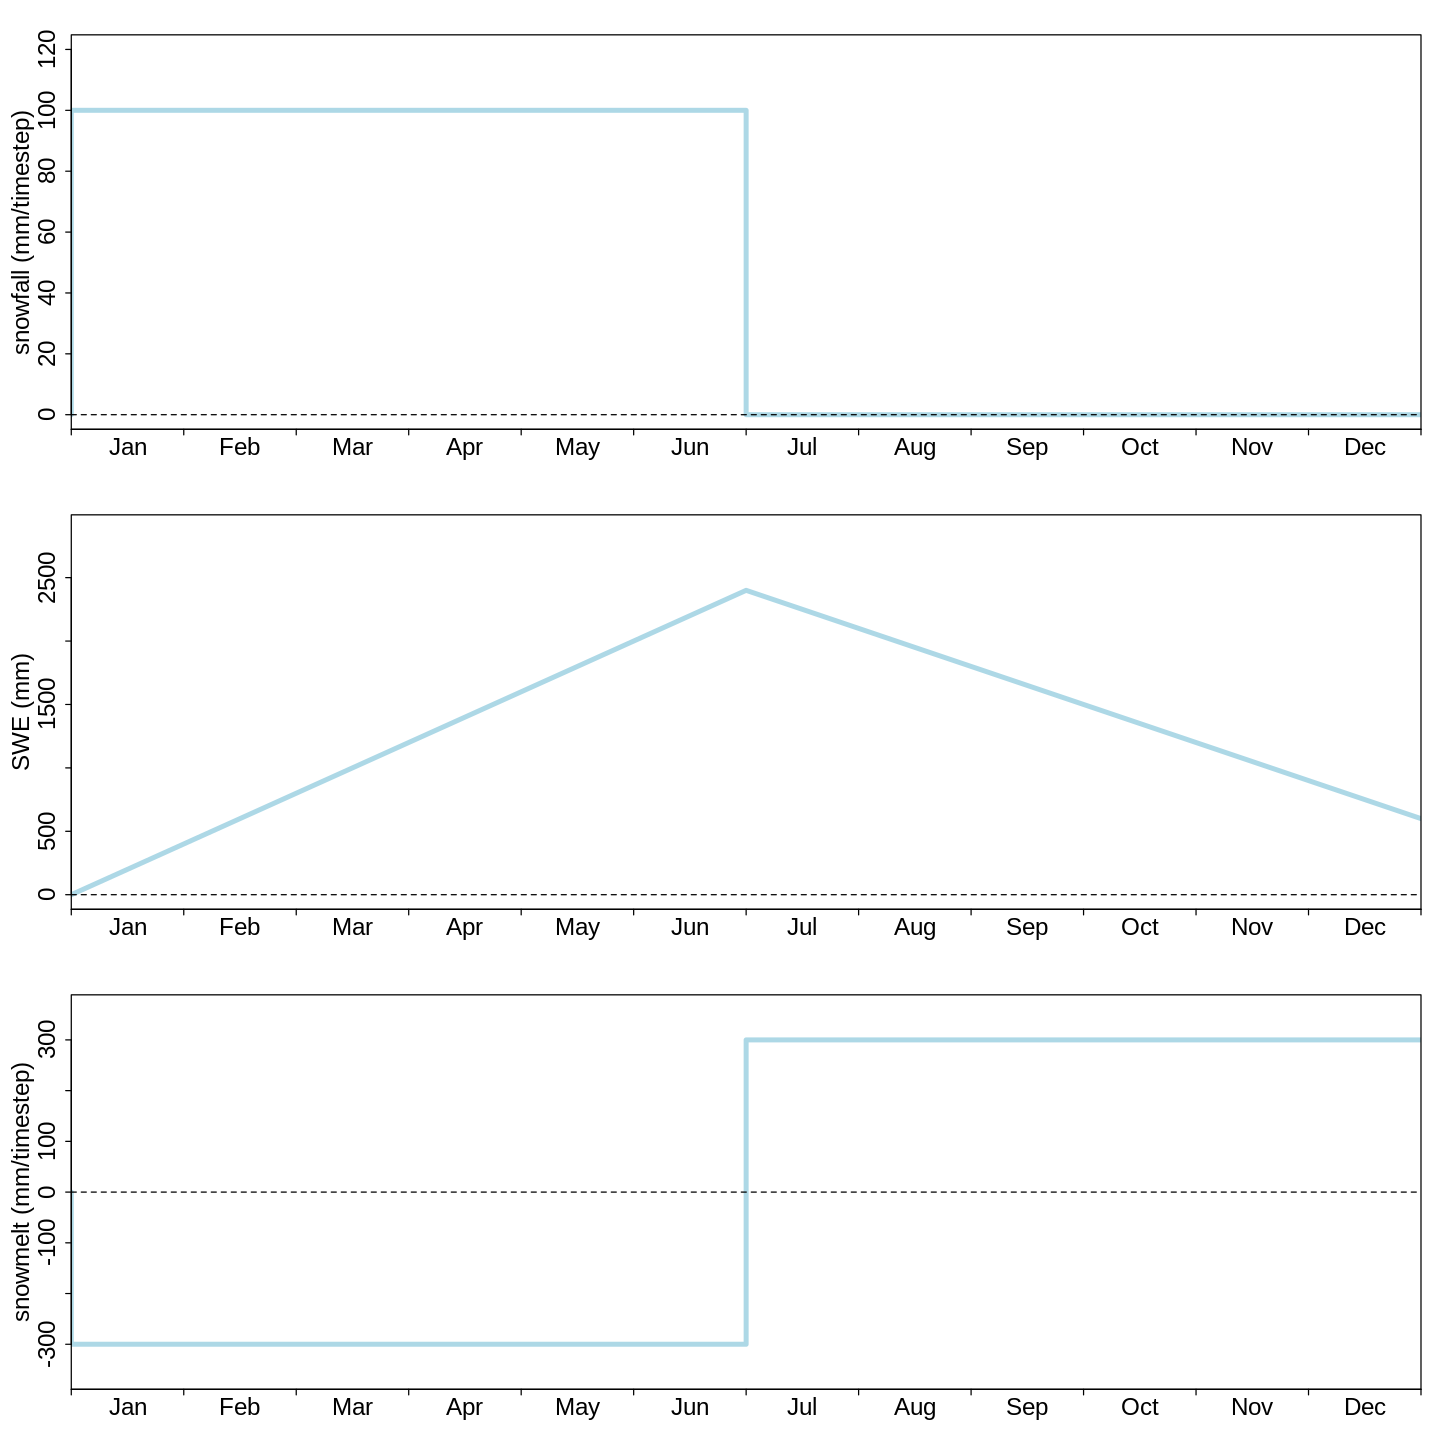

In [3]:
plot_tabella <- function(tab, tab2 = NULL, ts = 1) {
  # This function plots snowfall, SWE, and snowmelt in three stacked panels.
  # The argument ts is used only for plotting SWE when a high-resolution
  # synthetic time step is created by repeating the monthly values.

  add_initial_row <- function(x) {
    initial <- x[1, ]
    initial["t"] <- 0
    initial["snowfall"] <- 0
    initial["SWE"] <- 0
    initial["snowmelt"] <- 0
    rbind(initial, x)
  }

  tab <- add_initial_row(tab)

  add_month_axis <- function(xmax) {
    axis(
      1,
      at = seq(xmax / 12 / 2, xmax, by = xmax / 12),
      labels = month.abb,
      tick = FALSE
    )
    axis(
      1,
      at = seq(0, xmax, by = xmax / 12),
      labels = FALSE,
      tick = TRUE
    )
    abline(h = 0, lty = 2)
  }

  nice_ylim <- function(y) {
    r <- range(y, na.rm = TRUE)
    if (r[1] == r[2]) {
      return(r + c(-1, 1))
    }
    r * 1.2
  }

  xmax <- max(tab[, "t"])

  layout(matrix(1:3, ncol = 1))

  plot(
    tab[, "t"], tab[, "snowfall"],
    type = "S", lwd = 4, col = "#ADD8E6",
    ylim = nice_ylim(tab[, "snowfall"]),
    xlab = "", ylab = "snowfall (mm/timestep)", xaxt = "n"
  )
  add_month_axis(xmax)

  if (!is.null(tab2)) {
    tab2 <- add_initial_row(tab2)
    lines(tab2[, "t"], tab2[, "snowfall"], type = "S", lwd = 4, col = "#FF0000")
  }

  plot(
    tab[, "t"], tab[, "SWE"] / ts,
    type = "l", lwd = 4, col = "#ADD8E6",
    ylim = nice_ylim(tab[, "SWE"] / ts),
    xlab = "", ylab = "SWE (mm)", xaxt = "n"
  )
  add_month_axis(xmax)

  if (!is.null(tab2)) {
    lines(tab2[, "t"], tab2[, "SWE"] / ts, type = "l", lwd = 4, col = "#FF0000")
  }

  plot(
    tab[, "t"], tab[, "snowmelt"],
    type = "S", lwd = 4, col = "#ADD8E6",
    ylim = nice_ylim(tab[, "snowmelt"]),
    xlab = "", ylab = "snowmelt (mm/timestep)", xaxt = "n"
  )
  add_month_axis(xmax)

  if (!is.null(tab2)) {
    lines(tab2[, "t"], tab2[, "snowmelt"], type = "S", lwd = 4, col = "#FF0000")
  }
}

options(repr.plot.width = 12, repr.plot.height = 12)
par(ps=22, mar=c(3.2, 4.5, 2.2, 1.2), mgp=c(2.5, 0.8, 0), tcl=-0.35, xaxs="i", yaxs="r", las=0)
plot_tabella(snowmodel01(rep(P_s, each=30), rep(Tdeg, each=30), k_DDF=30), ts=30)


The plot reveals the problem immediately: during the cold period, melt is negative and snow storage increases for the wrong reason. The model is not accumulating snow only because snowfall is positive; it is also creating artificial snow because melt is negative.


## 4. Second attempt: prevent negative snowmelt

We now add the first constraint:

$$
M(t) = \max\{k_{DDF}[T(t)-T_m], 0\}
$$

This says that melt is zero when temperature is below the melt threshold.


In [4]:
snowmodel02 <- function (snowfall, temperature, k_DDF, Tmelt=0, SWE_0=0) {
  # snowfall = vector in mm/timestep
  # temperature = vector in degC
  # k_DDF = Degree Day Factor mm/(degC*timestep)
  tmax <- length(snowfall)
  snowmelt <- rep(NA, tmax)
  SWE <- rep(NA, tmax + 1)
   SWE[1] <- SWE_0
  for (t in 1:tmax) {
    snowmelt[t] <- max(c(k_DDF*(temperature[t] - Tmelt), 0))
    SWE[t+1] <- SWE[t] + snowfall[t] - snowmelt[t]
  }
  output <- cbind(t=1:tmax, snowfall=round(snowfall, 1),
                  temperature=round(temperature, 1), SWE=round(SWE[-1], 1),
                  snowmelt=round(snowmelt, 1))
  return(output)
}
snowmodel02(P_s, Tdeg, k_DDF=30)


t,snowfall,temperature,SWE,snowmelt
1,100,-10,100,0
2,100,-10,200,0
3,100,-10,300,0
4,100,-10,400,0
5,100,-10,500,0
6,100,-10,600,0
7,0,10,300,300
8,0,10,0,300
9,0,10,-300,300
10,0,10,-600,300


This fixes the negative-melt problem. However, it introduces a second problem: during the warm period, the potential melt can be larger than the amount of snow that is available.

If the model tries to melt more water than exists in the snowpack, `SWE` becomes negative. That is also physically impossible. The second numerical lesson is:

> A flux out of a storage cannot exceed the amount of water available in that storage.

For the snowpack, this means that actual melt must be limited by available `SWE`.


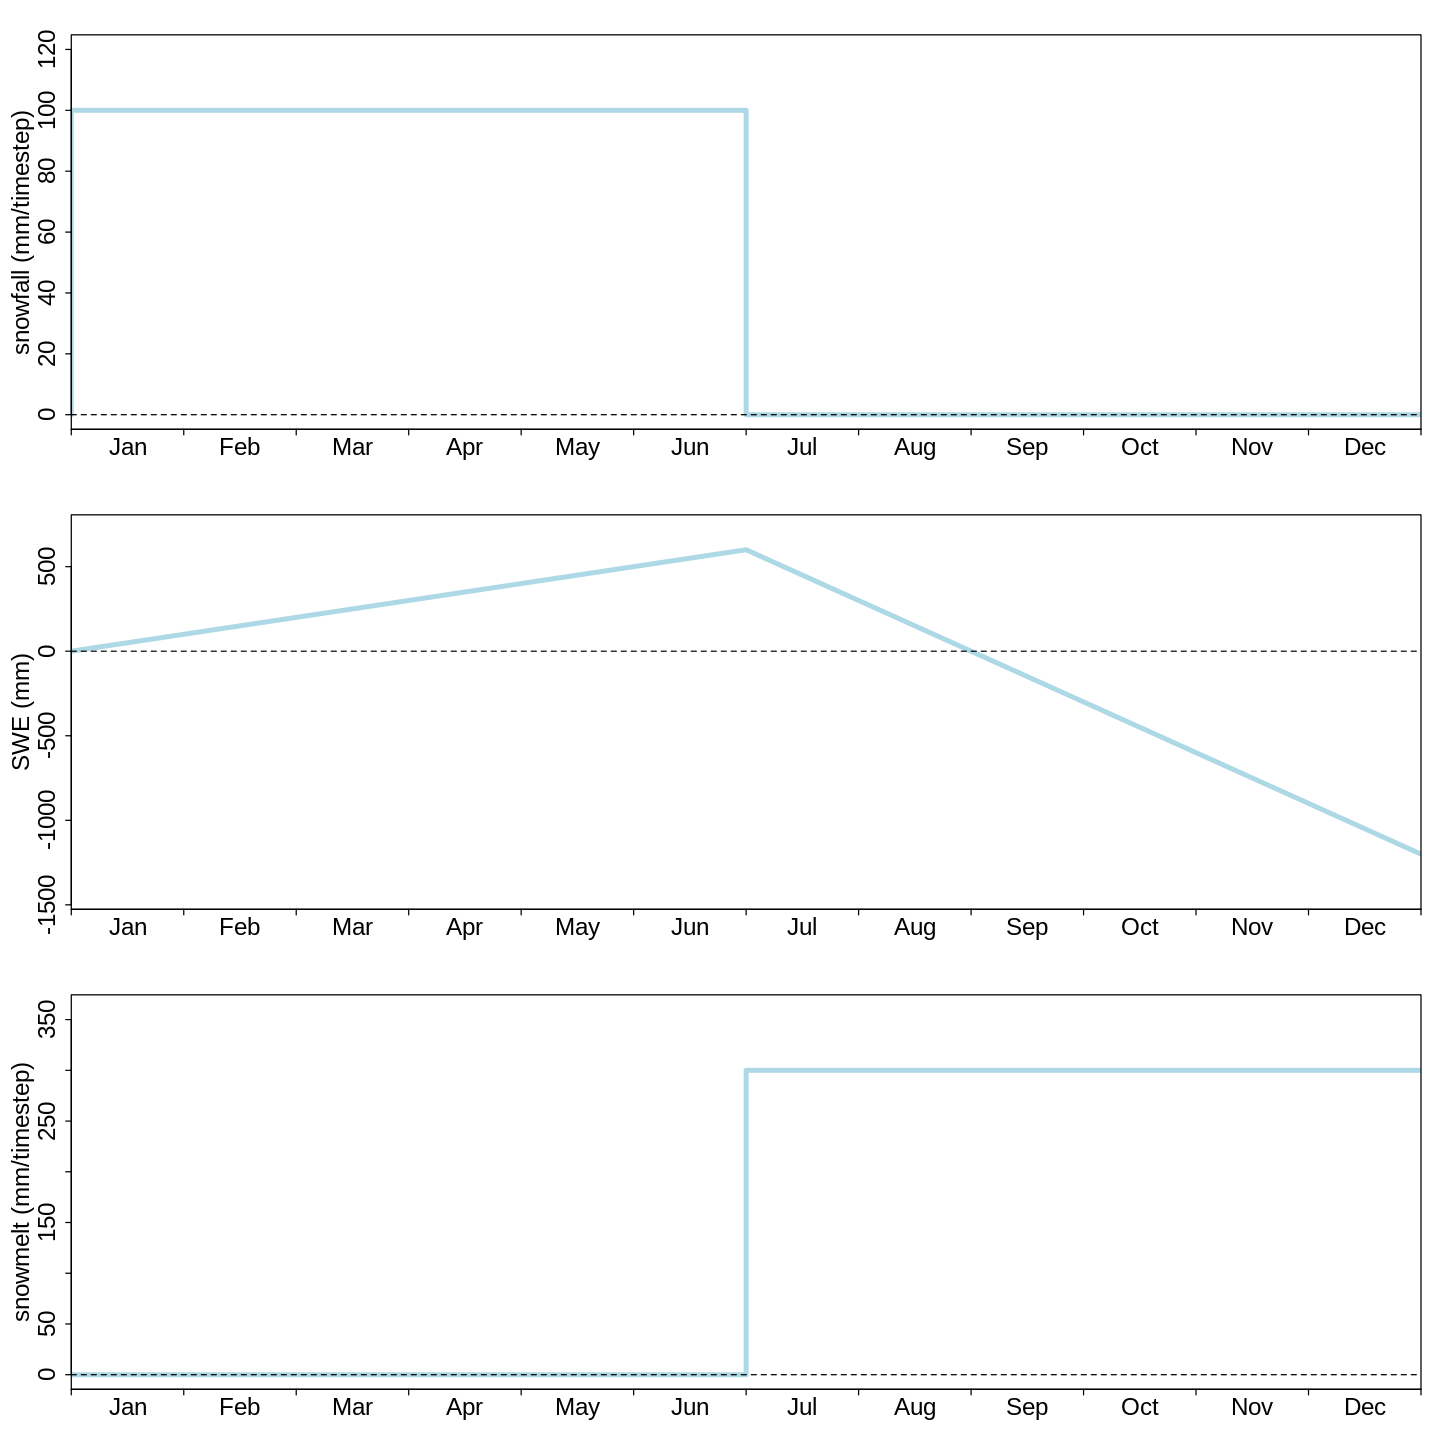

In [5]:
options(repr.plot.width = 12, repr.plot.height = 12)
par(ps=22, mar=c(3.2, 4.5, 2.2, 1.2), mgp=c(2.5, 0.8, 0), tcl=-0.35, xaxs="i", yaxs="r", las=0)
plot_tabella(snowmodel02(rep(P_s, each=30), rep(Tdeg, each=30), k_DDF=30), ts=30)


## 5. Third attempt: prevent negative snow storage

A tempting solution is to force the updated snow storage to remain non-negative:

$$
SWE_{t+1} = \max\{SWE_t + P_s(t) - M(t), 0\}
$$

This makes the storage look better, but it does not fully solve the water-balance problem.


In [6]:
snowmodel03 <- function (snowfall, temperature, k_DDF, Tmelt=0, SWE_0=0) {
  # snowfall = vector in mm/timestep
  # temperature = vector in degC
  # k_DDF = Degree Day Factor mm/(degC*timestep)
  tmax <- length(snowfall)
  snowmelt <- rep(NA, tmax)
  SWE <- rep(NA, tmax + 1)
   SWE[1] <- SWE_0
  for (t in 1:tmax) {
    snowmelt[t] <- max(c(k_DDF*(temperature[t] - Tmelt), 0))
    SWE[t+1] <- max(c(SWE[t] + snowfall[t] - snowmelt[t], 0))
  }
  output <- cbind(t=1:tmax, snowfall=round(snowfall, 1),
                  temperature=round(temperature, 1), SWE=round(SWE[-1], 1),
                  snowmelt=round(snowmelt, 1))
  return(output)
}
snowmodel03(P_s, Tdeg, k_DDF=30)


t,snowfall,temperature,SWE,snowmelt
1,100,-10,100,0
2,100,-10,200,0
3,100,-10,300,0
4,100,-10,400,0
5,100,-10,500,0
6,100,-10,600,0
7,0,10,300,300
8,0,10,0,300
9,0,10,0,300
10,0,10,0,300


### Why this is still not enough

The model now prevents `SWE` from becoming negative at the end of the time step. But the reported snowmelt can still be too large.

For example, suppose 50 mm of snow is available and the degree-day formula predicts 300 mm of potential melt. The snowpack can release at most 50 mm. Setting the final `SWE` to zero hides the storage error, but the flux `snowmelt` is still wrong.

This is a common numerical modelling issue: correcting the state variable after the update is not always enough. The fluxes must also satisfy the water balance.


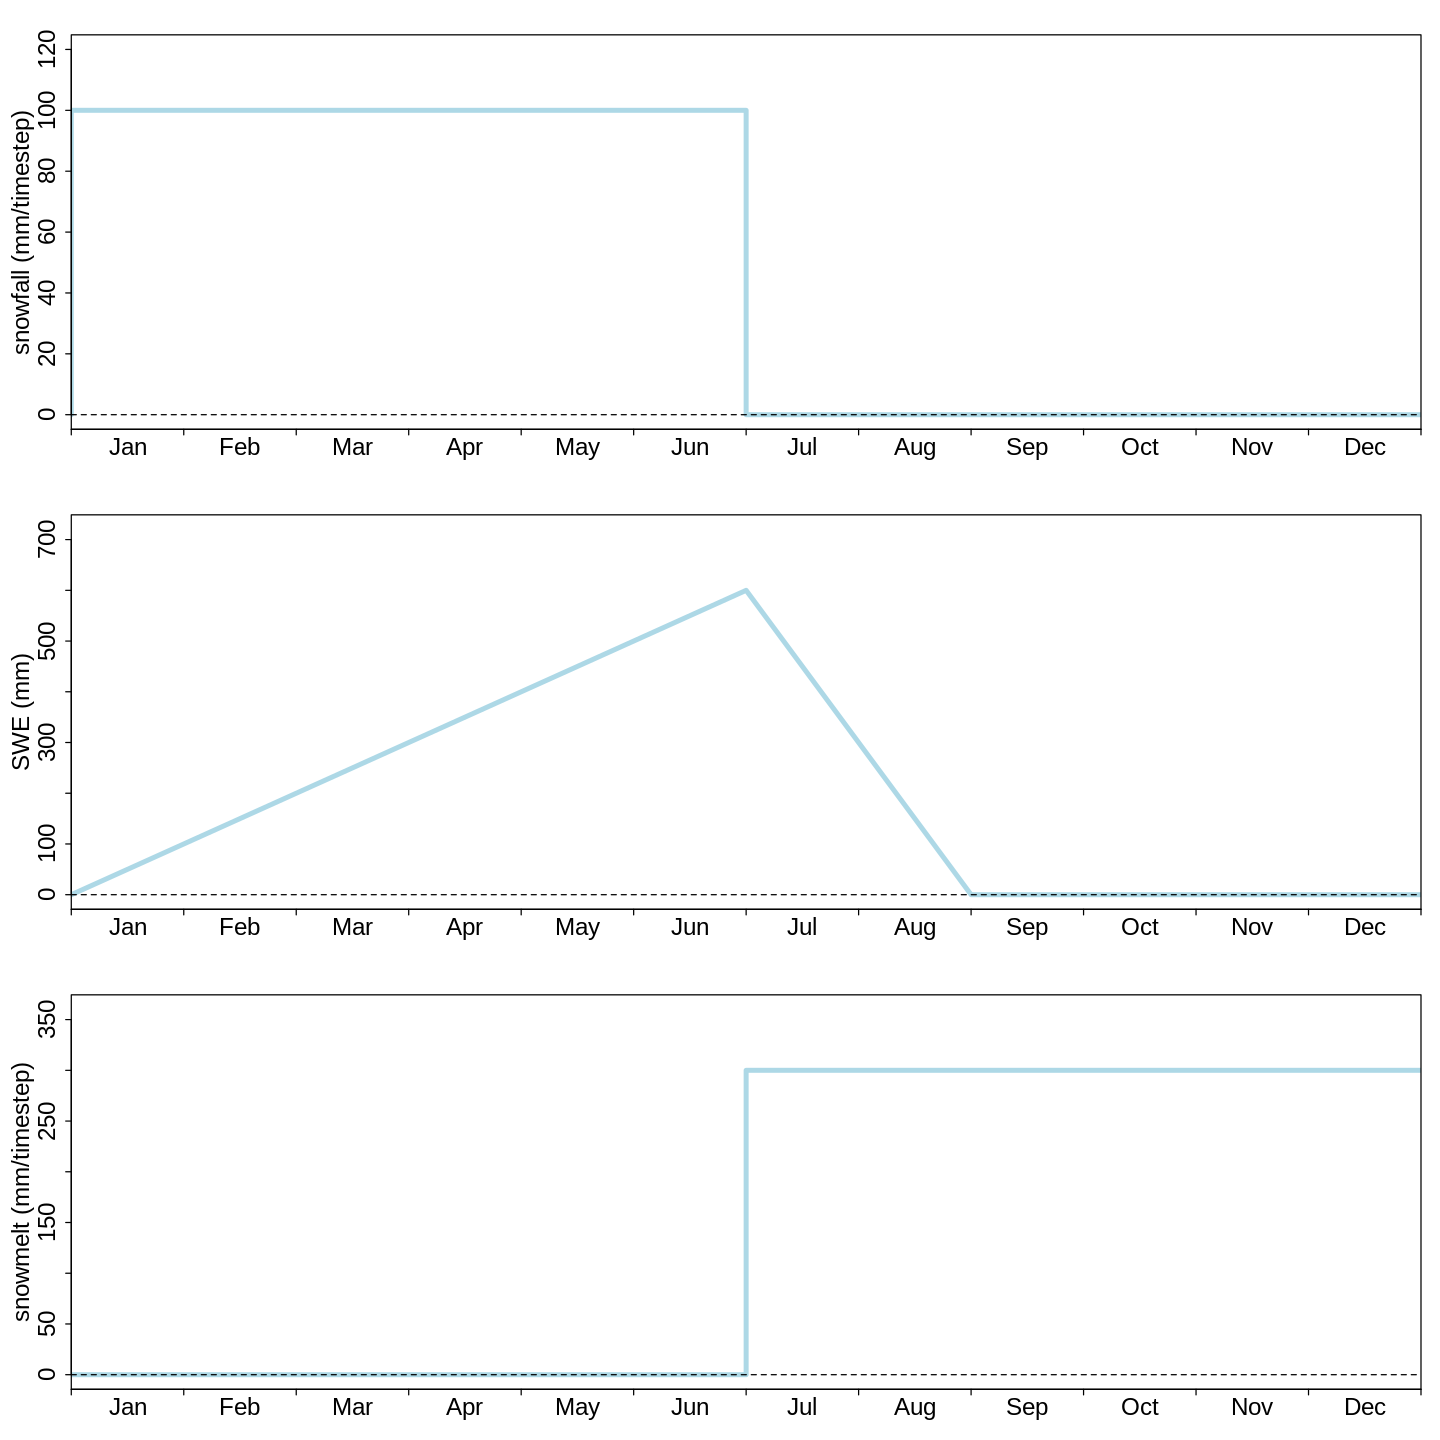

In [7]:
options(repr.plot.width = 12, repr.plot.height = 12)
par(ps=22, mar=c(3.2, 4.5, 2.2, 1.2), mgp=c(2.5, 0.8, 0), tcl=-0.35, xaxs="i", yaxs="r", las=0)
plot_tabella(snowmodel03(rep(P_s, each=30), rep(Tdeg, each=30), k_DDF=30), ts=30)


## 6. Fourth attempt: limit melt by available snow

The physically consistent solution is to limit actual melt by the amount of snow available at the time step:

$$
M(t) = \min\left(\max\{k_{DDF}[T(t)-T_m],0\}, SWE_t\right)
$$

This combines two constraints:

$$
M(t) \ge 0
$$

and

$$
M(t) \le SWE_t
$$

The first constraint prevents negative melt. The second prevents the model from melting more snow than exists.


In [8]:
snowmodel04 <- function (snowfall, temperature, k_DDF, Tmelt=0, SWE_0=0) {
  # snowfall = vector in mm/timestep
  # temperature = vector in degC
  # k_DDF = Degree Day Factor mm/(degC*timestep)
  tmax <- length(snowfall)
  snowmelt <- rep(NA, tmax)
  SWE <- rep(NA, tmax + 1)
   SWE[1] <- SWE_0
  for (t in 1:tmax) {
    snowmelt[t] <- min(max(c(k_DDF*(temperature[t] - Tmelt), 0)), SWE[t])
    SWE[t+1] <- max(c(SWE[t] + snowfall[t] - snowmelt[t], 0))
  }
  output <- cbind(t=1:tmax, snowfall=round(snowfall, 1),
                  temperature=round(temperature, 1), SWE=round(SWE[-1], 1),
                  snowmelt=round(snowmelt, 1))
  return(output)
}
snowmodel04(P_s, Tdeg, k_DDF=30)


t,snowfall,temperature,SWE,snowmelt
1,100,-10,100,0
2,100,-10,200,0
3,100,-10,300,0
4,100,-10,400,0
5,100,-10,500,0
6,100,-10,600,0
7,0,10,300,300
8,0,10,0,300
9,0,10,0,0
10,0,10,0,0


This fourth version is the first physically consistent implementation of the simple snow model.

A detail is worth noticing: snowmelt during a time step may be larger than the `SWE` shown at the end of that time step. That is not necessarily wrong. `snowmelt` is a **flux during the time step**, while `SWE` is a **storage after the time step has ended**.

For example, if the snowpack starts a time step with 150 mm of water and all of it melts, then:

- snowmelt during the time step is 150 mm;
- end-of-step `SWE` is 0 mm.

The comparison must therefore be made with the snow available at the beginning of the time step, not only with the storage reported at the end.


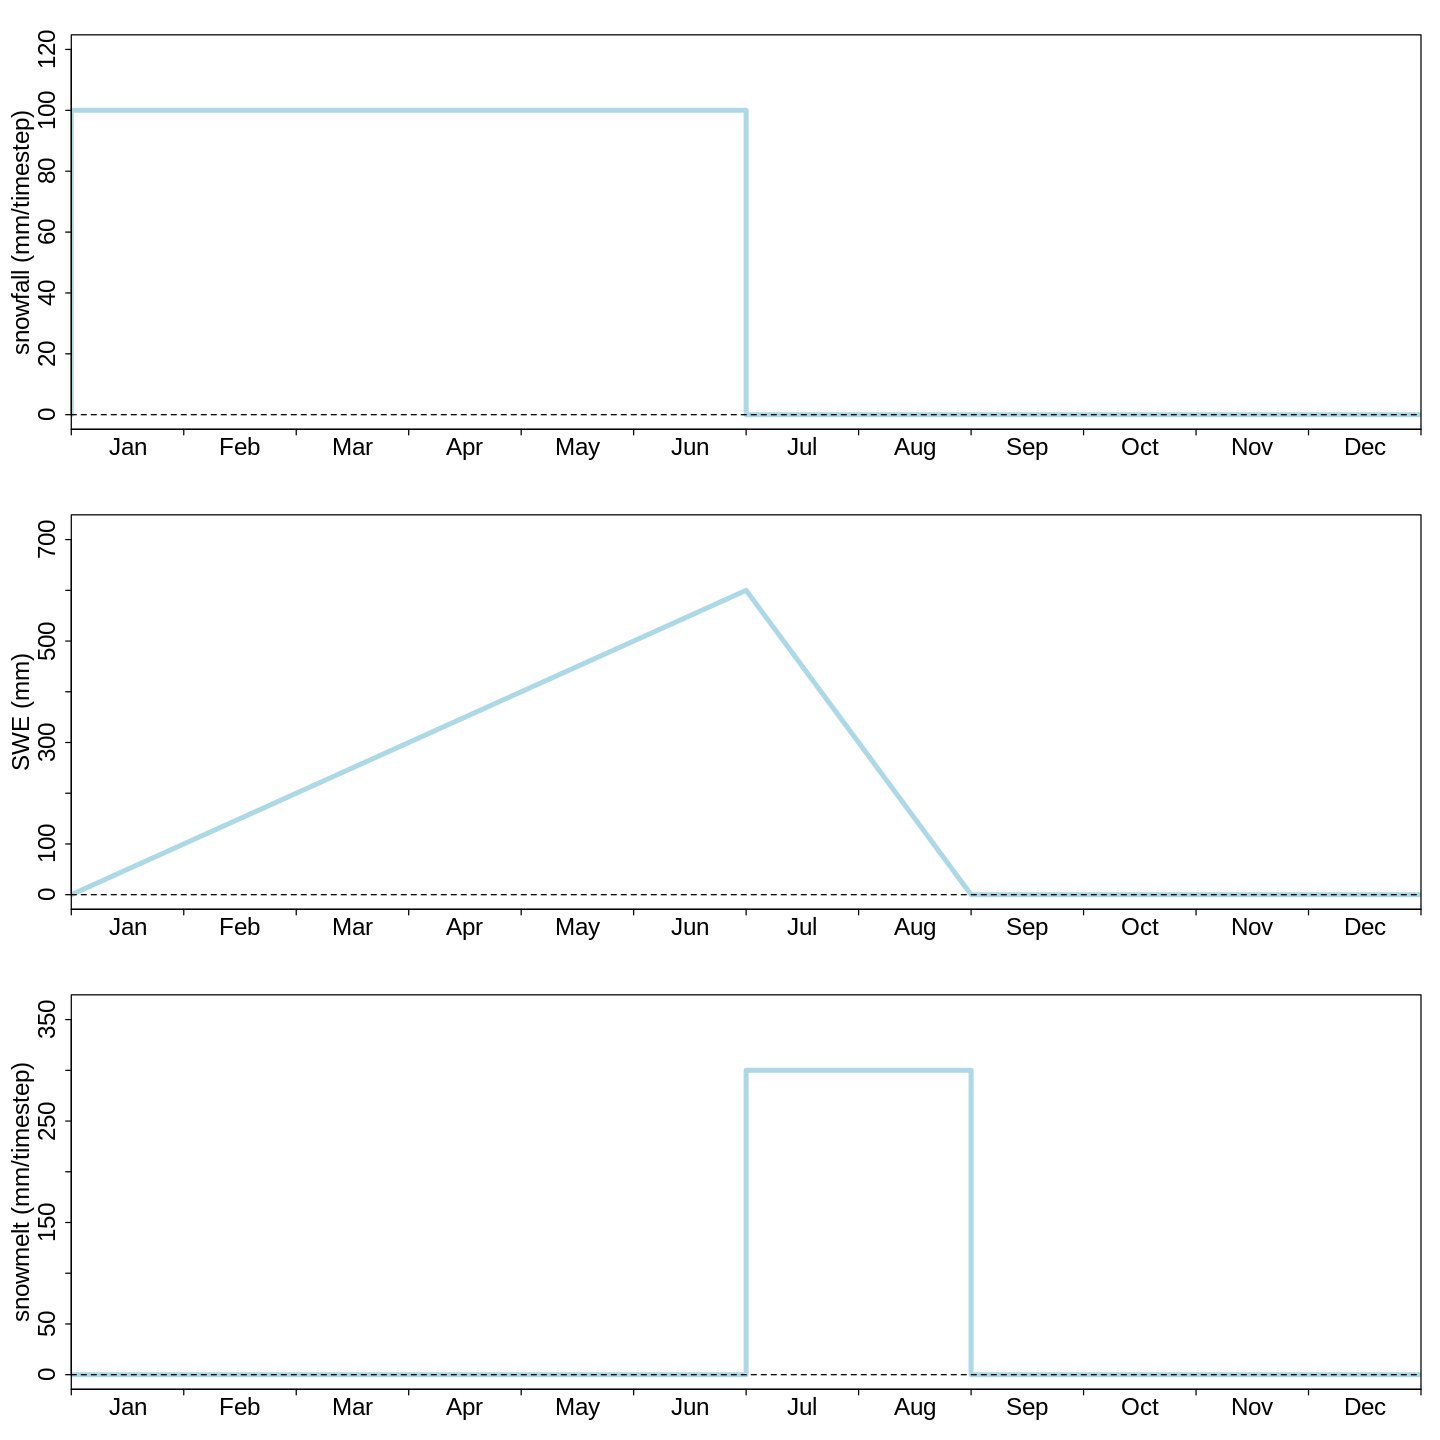

In [9]:
options(repr.plot.width = 12, repr.plot.height = 12)
par(ps=22, mar=c(3.2, 4.5, 2.2, 1.2), mgp=c(2.5, 0.8, 0), tcl=-0.35, xaxs="i", yaxs="r", las=0)
plot_tabella(snowmodel04(rep(P_s, each=30), rep(Tdeg, each=30), k_DDF=30), ts=30)


## 7. A discretization experiment

The last example compares two similar experiments. The blue line uses the original forcing: six cold snowy time steps followed by six warm dry time steps. The red line changes the timing so that the warm period begins one time step earlier.

This is a small change in the input sequence, but it can create a visible change in the melt timing and storage trajectory.

This illustrates an important modelling idea:

> In discrete-time models, the timing of inputs and transitions matters. A process that happens “within a month” or “within a day” must be assigned to a particular time step, and that choice can affect the result.

This is one reason why hydrological models may behave differently at monthly, weekly, and daily time steps.


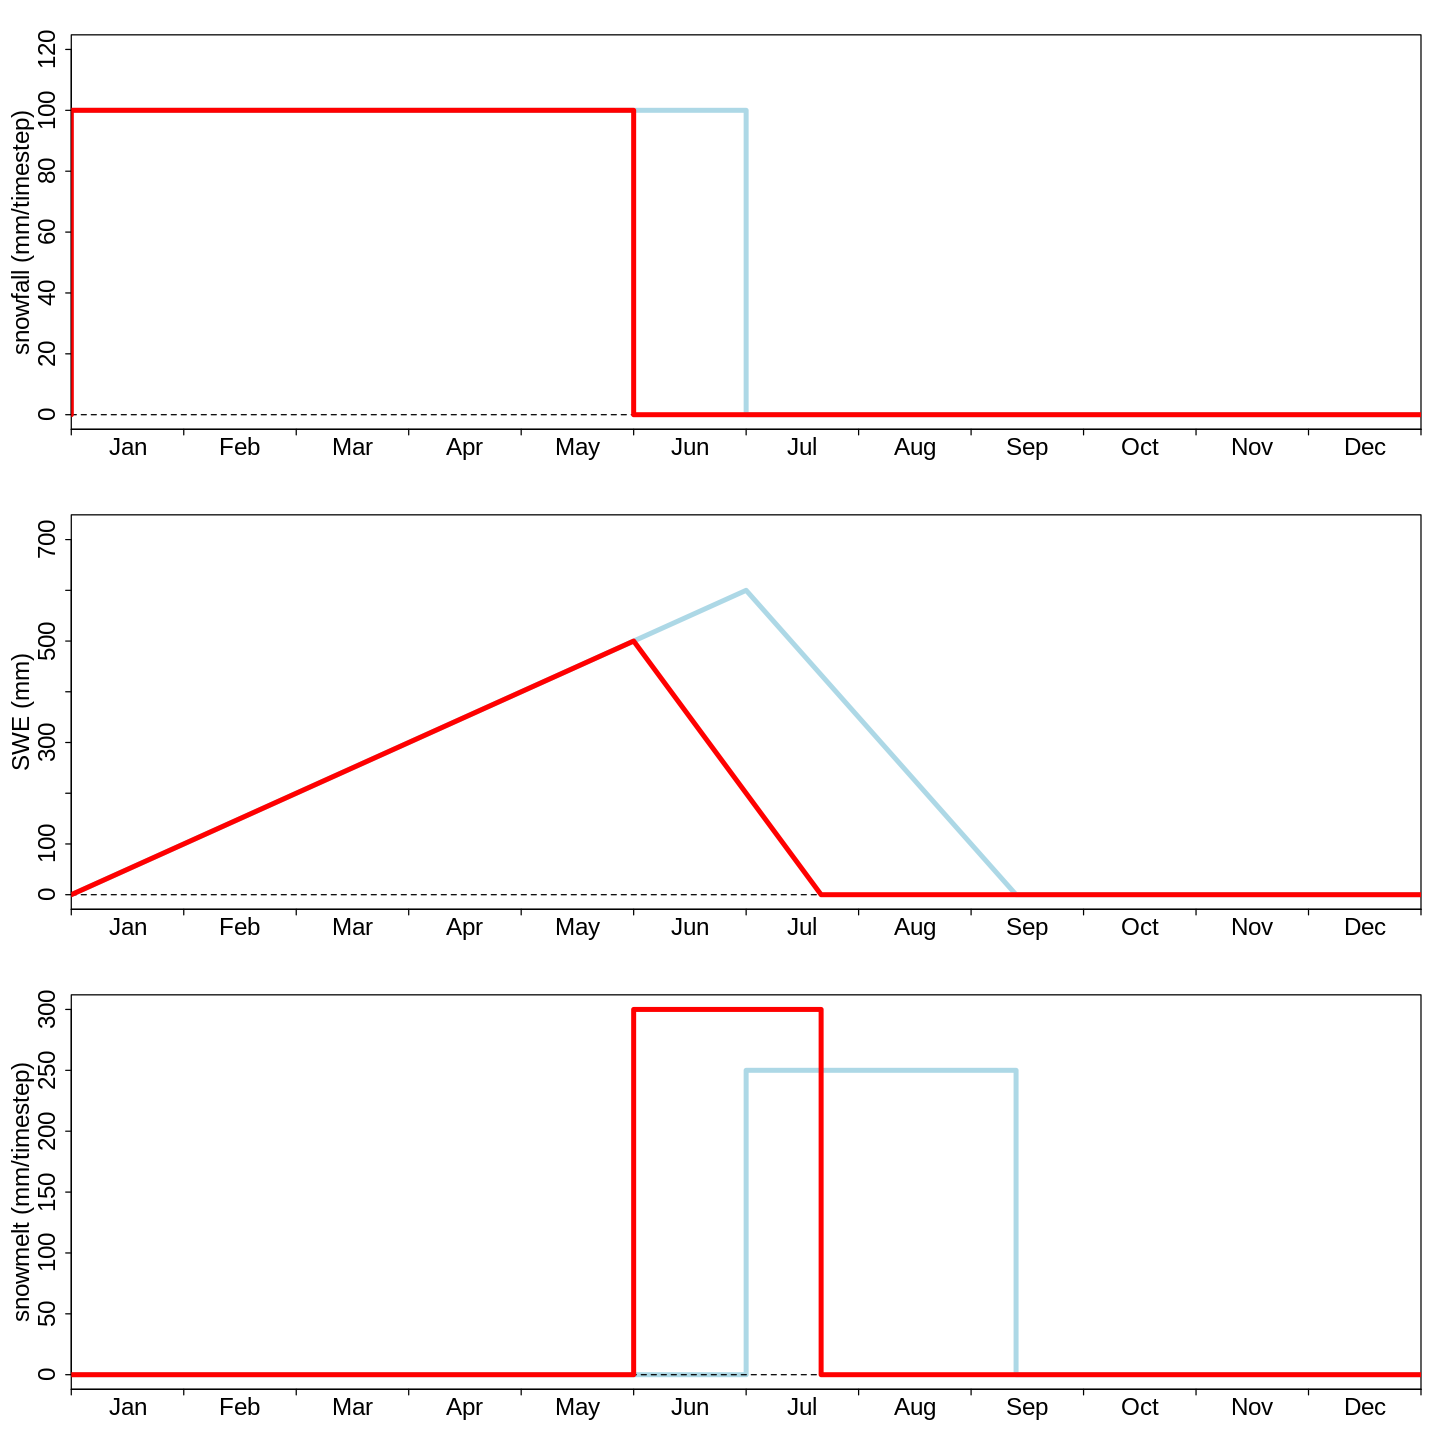

In [10]:
P_s2 <- c(100, 100, 100, 100, 100, 0,
          0, 0, 0, 0, 0, 0)
Tdeg2 <- c(-10, -10, -10, -10, -10, 10,
          10, 10, 10, 10, 10, 10)

options(repr.plot.width = 12, repr.plot.height = 12)
par(ps=22, mar=c(3.2, 4.5, 2.2, 1.2), mgp=c(2.5, 0.8, 0), tcl=-0.35, xaxs="i", yaxs="r", las=0)
plot_tabella(snowmodel04(rep(P_s, each=300), rep(Tdeg, each=300), k_DDF=25),
             snowmodel04(rep(P_s2, each=300), rep(Tdeg2, each=300), k_DDF=30), ts=300)


## 8. Summary: what this simple model teaches

This notebook introduced the degree-day factor method through four increasingly constrained snow models.

The model development followed this sequence:

1. **Start from the balance equation**  
   $$
   SWE_{t+1} = SWE_t + P_s(t) - M(t)
   $$

2. **Compute potential melt from temperature**  
   $$
   M_{pot}(t) = k_{DDF}[T(t)-T_m]
   $$

3. **Prevent negative melt**  
   $$
   M_{pot}(t) = \max\{k_{DDF}[T(t)-T_m],0\}
   $$

4. **Limit actual melt by available snow**  
   $$
   M(t) = \min\{M_{pot}(t), SWE_t\}
   $$

The main numerical modelling lessons are:

- state variables such as `SWE` must remain physically meaningful;
- fluxes such as `snowmelt` must also remain physically meaningful;
- a flux out of a storage cannot exceed the water available in that storage;
- the time step controls how events are ordered and represented;
- simple models are useful because they make these assumptions visible.

## Suggested student exercises

1. Change `k_DDF`. How does it affect the duration of the melt period?
2. Change `Tmelt` from 0 °C to 2 °C. What happens?
3. Make the warm period shorter. Can all snow melt before the end of the simulation?
4. Replace the step-change temperature with a sinusoidal seasonal temperature curve.
5. Modify `snowmodel04()` so that snowfall during a warm time step can melt immediately. Compare that version with the current one.
6. Repeat the same experiment at 12, 52, and 365 time steps. Which results change and which remain conceptually the same?
